This notebook focusses on the collinearity problem with linear regression.

We simulate a response $Y$ based on predictors $X_1$ and $X_2$ with relationship

$$Y = 2 + 2 X_1 + 0.3 X_2 + \epsilon $$

where $\epsilon$ is distributed $N(0, 1)$ and $X_2$ is correlated with $X_1$ with the relationship

$$X_2 = 0.5 X_1 + \delta$$

where $\delta$ is distributed $N(0, 0.01)$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(10)
x1 = rng.uniform(0, 1, size=100)
x2 = 0.5 * x1 + rng.normal(size=100) / 10
y = 2 + 2 * x1 + 0.3 * x2 + rng.normal(size=100)

We have generated $100$ observations of $(Y, X_1, X_2)$. Now we plot a scatter plot of the points $(X_1, X_2)$ (with $X_1$ on the horizontal axis and $X_2$ on the vertical axis) and calculate the correlation of $X_1, X_2$.

Correlation = 0.7723244976913541


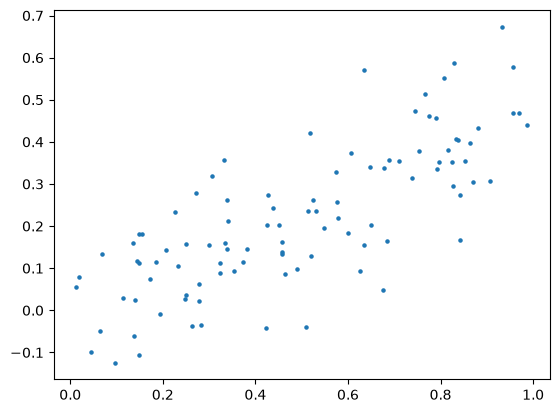

In [2]:
print(f'Correlation = {np.corrcoef(x1, x2)[1][0]}')
plt.scatter(x1, x2, s=5);

### Fitting a model of $Y$ on $X_1$ and $X_2$

We now fit a linear regression model to predict $Y$ using $X_1$ and $X_2$. 

The estimate for the constant $\beta_0$ is very close to the true value of $2$, but the estimates for $\beta_1$ (coefficient of $X_1$) and $\beta_2$ (coefficient of $X_2$) are quite far off from the true values of $2$ and $0.3$ respecively.\
At a $5\%$ significance level, we can reject $H_0: \beta_1=0$, but not $H_0: \beta_2 = 0$.

In [3]:
import statsmodels.api as sm
import pandas as pd

X = pd.DataFrame({'x1':x1, 'x2':x2})
X['intercept'] = 1

linear_model = sm.OLS(y, X).fit()
print(linear_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.291
Model:                            OLS   Adj. R-squared:                  0.276
Method:                 Least Squares   F-statistic:                     19.89
Date:                Sun, 30 Aug 2026   Prob (F-statistic):           5.76e-08
Time:                        21:24:48   Log-Likelihood:                -130.62
No. Observations:                 100   AIC:                             267.2
Df Residuals:                      97   BIC:                             275.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             1.6154      0.527      3.065      0.0

Plotting the residuals against leverage of the observations, we see that there are no real outliers, but there is one high leverage point way above the mean leverage.

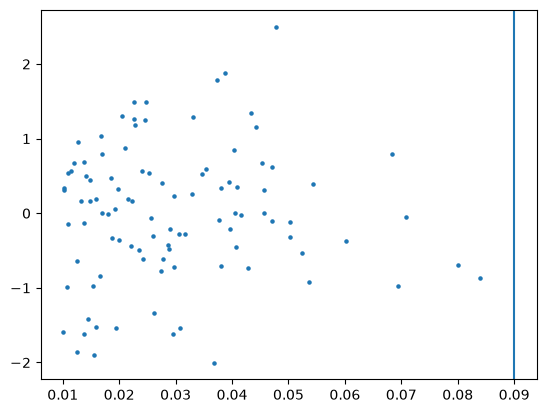

In [4]:
residuals = linear_model.resid
leverage = linear_model.get_influence().hat_matrix_diag

average_leverage = np.mean(leverage)

plt.scatter(leverage, residuals, s=5);
plt.axvline(3*average_leverage);

### Fitting a model of $Y$ on $X_1$

Now fit a least square regression to predict `y` using only `x1`. 

Both the estimates of $\beta_0$ and $\beta_1$ are close to the true values.\
We can reject the null hypothesis $H_0: \beta_1 = 0$ at a $5\%$ significance level.

In [5]:
X1 = pd.DataFrame({'x1':x1})
X1['intercept'] = 1

linear_model_1 = sm.OLS(y, X1).fit()
print(linear_model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.281
Model:                            OLS   Adj. R-squared:                  0.274
Method:                 Least Squares   F-statistic:                     38.39
Date:                Sun, 30 Aug 2026   Prob (F-statistic):           1.37e-08
Time:                        21:24:48   Log-Likelihood:                -131.28
No. Observations:                 100   AIC:                             266.6
Df Residuals:                      98   BIC:                             271.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             2.0771      0.335      6.196      0.0

Once again we plot the residuals against leverage of the observations. Now there are a few outlier points, but no high leverage points.

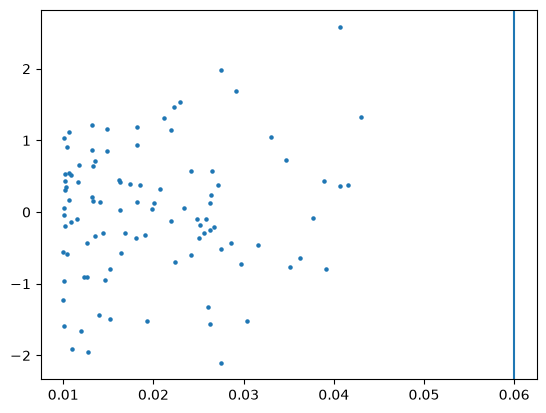

In [6]:
residuals_1 = linear_model_1.resid
leverage_1 = linear_model_1.get_influence().hat_matrix_diag

average_leverage_1 = np.mean(leverage_1)

plt.scatter(leverage_1, residuals_1, s=5);
plt.axvline(3*average_leverage_1);

### Fitting a model of $Y$ on $X_2$

Now fit a least squares regression to predict `y` using only `x2`.

The estimate for $\beta_0$ is somewhat far from the true value, and the estimate for $\beta_2$ is very far from the true value.\
However, at a $5\%$ significance level, we can reject $H_0: \beta_2 = 0$.

In [7]:
X2 = pd.DataFrame({'x2':x2})
X2['intercept'] = 1

linear_model_2 = sm.OLS(y, X2).fit()
print(linear_model_2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.222
Model:                            OLS   Adj. R-squared:                  0.214
Method:                 Least Squares   F-statistic:                     27.99
Date:                Sun, 30 Aug 2026   Prob (F-statistic):           7.43e-07
Time:                        21:24:48   Log-Likelihood:                -135.24
No. Observations:                 100   AIC:                             274.5
Df Residuals:                      98   BIC:                             279.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x2             2.9103      0.550      5.291      0.0

The residuals against leverage plot this time round suggests there are no outliers, but there are two high-leverage points.

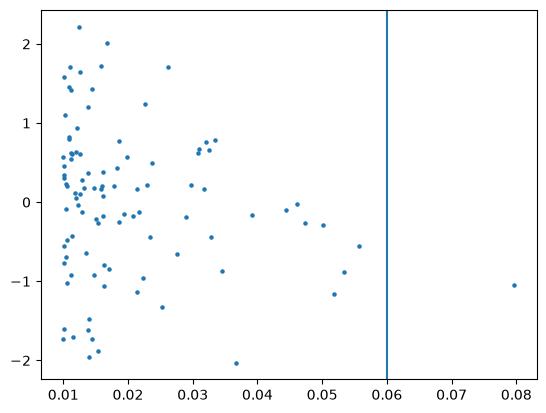

In [8]:
residuals_2 = linear_model_2.resid
leverage_2 = linear_model_2.get_influence().hat_matrix_diag

average_leverage_2 = np.mean(leverage_2)

plt.scatter(leverage_2, residuals_2, s=5);
plt.axvline(3*average_leverage_2);

### Making sense of the three models

The model of $Y$ on $X_2$ gave wildly inaccurate estimates for $\beta_2$. When $X_2$ and $X_1$ are approximately linearly related, then the linear relationship

$$Y = 2 + 2X_1 + 0.3X_2 + \epsilon$$

can be written in different ways by substituting the linear relationship $X_2 \approx 0.5 X_1$. Substituting three times of this into the linear relationship between $Y$ and $X_1, X_2$, we would get

$$Y \approx 2 + 0.5X_1 + 3.3X_2 + \epsilon$$

Substituting four times of this, we would get

$$Y \approx 2 + 4.3X_2 + \epsilon$$

All these approximately equivalent ways of writing the linear relationship between $Y$ and $X_1, X_2$ give wildly different coefficients of $X_2$. This is why our $Y$ on $X_2$ model did not produce coefficient estimates of around $0.3$ - it cannot separate out the effects of $X_1$ and $X_2$.

### Instability of the coefficient estimates

Suppose we add in one more set of observation $(Y, X_1, X_2) = (6, 0.1, 0.8)$. How will this change our coefficient estimates?

For the model of $Y$ on $X_1$ and $X_2$, the coefficient estimates changed from $(\beta_0, \beta_1, \beta_2) = (2.0618, 0.8575, 2.2663)$ to $(2.1121, 0.4907, 2.9070)$.

For the model of $Y$ on $X_1$, the coefficient estimates changed from $(\beta_0, \beta_1) = (2.0739, 1.8760)$ to $(2.2027, 1.6868)$.

For the model of $Y$ on $X_2$, the coefficient estimates changed from $(\beta_0, \beta_2) = (2.2840, 3.1458)$ to $(2.2521, 3.3346)$.

In all three cases, the coefficient estimates changed significantly, suggesting collinear data gives a highly unstable fit. Even one observation has the potential to change the coefficient estimates dramatically.

In [9]:
x1 = np.concatenate([x1, [0.1]])
x2 = np.concatenate([x2, [0.8]])
y = np.concatenate([y, [6]])

X = pd.DataFrame({'x1':x1, 'x2':x2})
X['intercept'] = 1

refit_model = sm.OLS(y, X).fit()
print(refit_model.summary())

X1 = pd.DataFrame({'x1':x1})
X1['intercept'] = 1

refit_model_1 = sm.OLS(y, X1).fit()
print(refit_model_1.summary())

X2 = pd.DataFrame({'x2':x2})
X2['intercept'] = 1

refit_model_2 = sm.OLS(y, X2).fit()
print(refit_model_2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.292
Model:                            OLS   Adj. R-squared:                  0.277
Method:                 Least Squares   F-statistic:                     20.17
Date:                Sun, 30 Aug 2026   Prob (F-statistic):           4.60e-08
Time:                        21:24:48   Log-Likelihood:                -135.30
No. Observations:                 101   AIC:                             276.6
Df Residuals:                      98   BIC:                             284.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.8575      0.466      1.838      0.0

We make residual against leverage plots for the new data set. These plots reveal that the additional observation is
* a leverage point for the multiple linear regression model
* an outlier point for the simple linear regression model of $Y$ on $X_1$
* a leverage point for the simple linear regression model of $Y$ on $X_2$

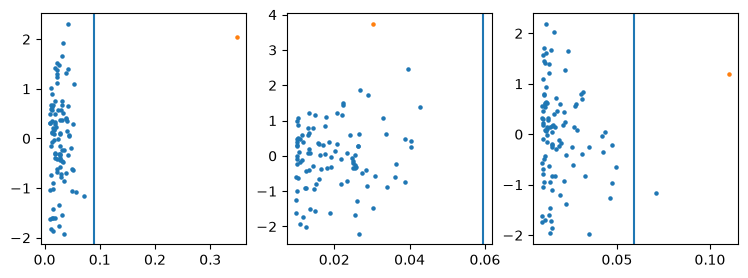

In [10]:
refit_resid = refit_model.resid
refit_resid_1 = refit_model_1.resid
refit_resid_2 = refit_model_2.resid

refit_leverage = refit_model.get_influence().hat_matrix_diag
refit_leverage_1 = refit_model_1.get_influence().hat_matrix_diag
refit_leverage_2 = refit_model_2.get_influence().hat_matrix_diag

refit_mean = np.mean(refit_leverage)
refit_mean_1 = np.mean(refit_leverage_1)
refit_mean_2 = np.mean(refit_leverage_2)

diagnostic = plt.Figure(figsize=(9,3))
axs = diagnostic.subplots(nrows=1, ncols=3)

axs[0].scatter(refit_leverage[:-1], refit_resid[:-1], s=5)
axs[0].scatter(refit_leverage[-1:], refit_resid[-1:], s=5)
axs[0].axvline(3*refit_mean)

axs[1].scatter(refit_leverage_1[:-1], refit_resid_1[:-1], s=5)
axs[1].scatter(refit_leverage_1[-1:], refit_resid_1[-1:], s=5)
axs[1].axvline(3*refit_mean_1)

axs[2].scatter(refit_leverage_2[:-1], refit_resid_2[:-1], s=5)
axs[2].scatter(refit_leverage_2[-1:], refit_resid_2[-1:], s=5)
axs[2].axvline(3*refit_mean_2)

diagnostic